# Static vs Dynamic Language Bucket Probe

This notebook contains the full experiment in one place. The goal is to test whether Qwen's internal representations separate code from statically typed languages and dynamically typed languages, and then compare that result against random language-bucket controls.

The important control is: keep the same programs, the same model activations, the same train/test split, and the same linear probe. Only change the mapping from language to label.

## Experiment Setup

Real labels:

- Label `1`, static: `C`, `C#`, `C++`, `Java`
- Label `0`, dynamic: `Javascript`, `PHP`, `Python`

Exhaustive controls:

- Enumerate **all** C(7, 4) = 35 ways to assign exactly 4 of the 7 languages to label `1`
- **Exclude** the one combination that matches the real static/dynamic split, leaving **34** alternative bucketing schemes
- Assign the remaining 3 languages to label `0`
- Run the exact same probe for every combination

Interpretation:

- If static/dynamic performs much better than all 34 alternative buckets, that supports a meaningful typing-related signal.
- If many alternative buckets perform similarly, the probe may mostly be detecting language identity.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch

if torch.cuda.is_available():
    print(f"Success! Connected to GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Not connected to a GPU. Check your Colab runtime settings.")

Success! Connected to GPU: NVIDIA A100-SXM4-40GB


In [3]:
from __future__ import annotations

import hashlib
import json
from collections import defaultdict
from itertools import combinations
from pathlib import Path
from typing import Dict, Iterable, Iterator, List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_colwidth', 160)

ROOT = Path.cwd().resolve()
if ROOT.name == 'language_bucket_control':
    ROOT = ROOT.parent

CONTROL_DIR = ROOT / 'language_bucket_control'
DATA_ROOT = Path('/content/drive/MyDrive/Ark Algoverse/data/XLCoST_data/retrieval/code2code_search/program_level')
DATA_DIR = CONTROL_DIR / 'data'
ACTIVATION_DIR = CONTROL_DIR / 'activations/qwen25_coder_1p5b_mean'
RESULTS_DIR = CONTROL_DIR / 'results'

STATIC_LANGUAGES = ['C', 'C#', 'C++', 'Java']
DYNAMIC_LANGUAGES = ['Javascript', 'PHP', 'Python']
LANGUAGES = STATIC_LANGUAGES + DYNAMIC_LANGUAGES
SPLITS = ['train', 'val', 'test']

MODEL_NAME = 'Qwen/Qwen2.5-Coder-1.5B'
LIMIT_PER_LANGUAGE_SPLIT = 1000
SEED = 0

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Build Full-Program Dataset

XLCoST has both snippet-level and program-level versions. We use `program_level` here because the unit of the experiment should be a complete program, not an isolated line fragment.

In [4]:
def xlcost_tokens_to_code(tokens: Sequence[str]) -> str:
    lines: List[str] = []
    current: List[str] = []
    indent = 0

    def flush() -> None:
        nonlocal current
        if current:
            lines.append(('    ' * indent) + ' '.join(current).strip())
            current = []

    for tok in tokens:
        if tok == 'NEW_LINE':
            flush()
        elif tok == 'INDENT':
            flush()
            indent += 1
        elif tok == 'DEDENT':
            flush()
            indent = max(0, indent - 1)
        elif tok == 'STRNEWLINE':
            current.append('\\n')
        else:
            current.append(tok)
    flush()
    return '\n'.join(lines).strip()


def language_bucket(language: str) -> str:
    if language in STATIC_LANGUAGES:
        return 'static'
    if language in DYNAMIC_LANGUAGES:
        return 'dynamic'
    raise ValueError(f'Unknown language: {language}')


def language_label(language: str) -> int:
    return int(language_bucket(language) == 'static')


def iter_language_split(language: str, split: str) -> Iterator[dict]:
    path = DATA_ROOT / language / f'{split}.jsonl'
    with path.open('r', encoding='utf-8') as handle:
        for line in handle:
            row = json.loads(line)
            yield {
                'snippet_id': str(row.get('url') or row['idx']),
                'language': language,
                'split': split,
                'code': xlcost_tokens_to_code(row['docstring_tokens']),
            }


def write_jsonl(path: Path, rows: Iterable[dict]) -> int:
    count = 0
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as handle:
        for row in rows:
            handle.write(json.dumps(row, ensure_ascii=False) + '\n')
            count += 1
    return count


def all_language_assignments() -> List[Dict[str, int]]:
    """Return all C(7, 4) = 35 possible assignments of 4 languages to label 1,
    excluding the real static/dynamic assignment so it does not contaminate controls."""
    real_positive = frozenset(STATIC_LANGUAGES)
    assignments = []
    for positive_langs in combinations(LANGUAGES, len(STATIC_LANGUAGES)):
        positive_set = frozenset(positive_langs)
        if positive_set == real_positive:
            continue  # skip — this is the real static/dynamic split
        assignments.append({lang: int(lang in positive_set) for lang in LANGUAGES})
    return assignments  # 34 alternative bucketing schemes


def build_dataset(limit_per_language_split: Optional[int] = LIMIT_PER_LANGUAGE_SPLIT) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for language in LANGUAGES:
            for count, row in enumerate(iter_language_split(language, split), start=1):
                row['label'] = language_label(language)
                row['bucket'] = language_bucket(language)
                row['experiment'] = 'static_dynamic'
                rows.append(row)
                if limit_per_language_split and count >= limit_per_language_split:
                    break

    dataset_path = DATA_DIR / 'static_dynamic.jsonl'
    write_jsonl(dataset_path, rows)

    summary = (
        pd.DataFrame(rows)
        .groupby(['experiment', 'split', 'language', 'label', 'bucket'])
        .size()
        .rename('count')
        .reset_index()
    )
    summary.to_json(DATA_DIR / 'summary.jsonl', orient='records', lines=True)

    all_assignments = all_language_assignments()
    manifest = {
        'static_languages': STATIC_LANGUAGES,
        'dynamic_languages': DYNAMIC_LANGUAGES,
        'label_1': 'static for static_dynamic; positive bucket for all_bucket_combos',
        'label_0': 'dynamic for static_dynamic; negative bucket for all_bucket_combos',
        'limit_per_language_split': limit_per_language_split,
        'all_bucket_combos': [
            {
                'experiment': f'language_bucket_combo_{i}',
                'assignment': assignment,
            }
            for i, assignment in enumerate(all_assignments)
        ],
    }
    with (DATA_DIR / 'manifest.json').open('w', encoding='utf-8') as handle:
        json.dump(manifest, handle, indent=2, ensure_ascii=False)

    print(f'Wrote {len(rows)} full-program examples to {dataset_path}')
    print(f'Wrote {len(all_assignments)} bucket combinations (C(7,4)=35 minus the real static/dynamic split = 34) to {DATA_DIR / "manifest.json"}')
    return summary

In [5]:
summary = build_dataset()
summary.sort_values(['split', 'language'])

Wrote 19471 full-program examples to /content/language_bucket_control/data/static_dynamic.jsonl
Wrote 34 bucket combinations (C(7,4)=35 minus the real static/dynamic split = 34) to /content/language_bucket_control/data/manifest.json


,experiment,split,language,label,bucket,count
0,static_dynamic,test,C,1,static,283
1,static_dynamic,test,C#,1,static,1000
2,static_dynamic,test,C++,1,static,1000
3,static_dynamic,test,Java,1,static,1000
4,static_dynamic,test,Javascript,0,dynamic,1000
5,static_dynamic,test,PHP,0,dynamic,1000
6,static_dynamic,test,Python,0,dynamic,1000
7,static_dynamic,train,C,1,static,1000
8,static_dynamic,train,C#,1,static,1000
9,static_dynamic,train,C++,1,static,1000


In [6]:
examples = pd.read_json(DATA_DIR / 'static_dynamic.jsonl', lines=True, nrows=3)
examples[['language', 'split', 'bucket', 'label', 'code']]

,language,split,bucket,label,code
0,C,train,static,1,"#include <stdio.h>\nvoid count_setbit ( int N ) { int result = 0 ; for ( int i = 0 ; i < 32 ; i ++ ) { if ( ( 1 << i ) & N ) { result ++ ; } } printf ( "" % ..."
1,C,train,static,1,#include <stdio.h>\n#include <math.h>\n_Bool isPowerOfTwo ( int n ) { return ( ceil ( log2 ( n ) ) == floor ( log2 ( n ) ) ) ; } int main ( ) { int N = 8 ; ...
2,C,train,static,1,"#include <stdio.h>\n#include <string.h>\nvoid search ( char pat [ ] , char txt [ ] ) { int M = strlen ( pat ) ; int N = strlen ( txt ) ; int i = 0 ; while (..."


## 2. Extract Qwen Activations

This step runs each program through Qwen and stores one vector per layer per program. The probe will train on these vectors, not on raw code text.

This is the slow step. If the activation files already exist, the cell will reuse them unless `FORCE_REEXTRACT = True`.

In [7]:
def read_jsonl(path: Path) -> List[dict]:
    with path.open('r', encoding='utf-8') as handle:
        return [json.loads(line) for line in handle]


def save_metadata(path: Path, metadata: Iterable[dict]) -> None:
    with path.open('w', encoding='utf-8') as handle:
        for row in metadata:
            handle.write(json.dumps(row, ensure_ascii=False) + '\n')


def record_key(record: dict) -> str:
    raw = f"{record['language']}::{record['split']}::{record['snippet_id']}::{record['code']}"
    return hashlib.sha1(raw.encode('utf-8')).hexdigest()


def group_records(records: Iterable[dict]) -> List[List[dict]]:
    grouped: Dict[str, List[dict]] = defaultdict(list)
    for record in records:
        grouped[record_key(record)].append(record)
    return list(grouped.values())


def activation_paths() -> Dict[str, Path]:
    ACTIVATION_DIR.mkdir(parents=True, exist_ok=True)
    return {
        'features': ACTIVATION_DIR / 'features.npy',
        'labels': ACTIVATION_DIR / 'labels.npy',
        'metadata': ACTIVATION_DIR / 'metadata.jsonl',
    }


def pick_device():
    import torch

    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def pool_layer(layer_hidden, attention_mask, pooling: str):
    valid = attention_mask.bool()
    if pooling == 'mean':
        return layer_hidden[valid].mean(dim=0)
    if pooling == 'last':
        last_idx = int(valid.nonzero()[-1])
        return layer_hidden[last_idx]
    raise ValueError(f'Unknown pooling: {pooling}')


def extract_qwen_activations(
    labels_path: Path = DATA_DIR / 'static_dynamic.jsonl',
    model_name: str = MODEL_NAME,
    batch_size: int = 4,
    max_length: int = 512,
    pooling: str = 'mean',
    force: bool = False,
) -> Dict[str, Path]:
    paths = activation_paths()
    if not force and all(path.exists() for path in paths.values()):
        print(f'Using cached activations in {ACTIVATION_DIR}')
        return paths

    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    records = read_jsonl(labels_path)
    grouped = group_records(records)
    device = pick_device()
    print(f'Loading {model_name} on {device}')

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    dtype = torch.float16 if device.type in {'cuda', 'mps'} else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )
    model.to(device)
    model.eval()

    all_features: List[np.ndarray] = []
    all_labels: List[int] = []
    all_metadata: List[dict] = []

    with torch.no_grad():
        for batch_start in range(0, len(grouped), batch_size):
            groups = grouped[batch_start : batch_start + batch_size]
            codes = [group[0]['code'] for group in groups]
            encoded = tokenizer(
                codes,
                return_tensors='pt',
                padding=True,
                truncation=True,
                max_length=max_length,
            )
            attention_mask = encoded['attention_mask']
            encoded = {key: value.to(device) for key, value in encoded.items()}
            outputs = model(**encoded, output_hidden_states=True, use_cache=False)
            hidden_by_layer = torch.stack([state.detach().float().cpu() for state in outputs.hidden_states])

            for item_idx, group in enumerate(groups):
                item_mask = attention_mask[item_idx]
                layer_vectors = []
                for layer_idx in range(hidden_by_layer.shape[0]):
                    pooled = pool_layer(hidden_by_layer[layer_idx, item_idx], item_mask, pooling)
                    layer_vectors.append(pooled.numpy())
                program_features = np.stack(layer_vectors, axis=0)

                for record in group:
                    all_features.append(program_features)
                    all_labels.append(int(record['label']))
                    meta = dict(record)
                    meta['pooling'] = pooling
                    all_metadata.append(meta)

            if batch_start and batch_start % 200 == 0:
                print(f'Processed {batch_start} / {len(grouped)} programs')

    features = np.stack(all_features, axis=0)
    labels = np.asarray(all_labels, dtype=np.int64)
    np.save(paths['features'], features)
    np.save(paths['labels'], labels)
    save_metadata(paths['metadata'], all_metadata)
    print(f'Wrote features {features.shape} to {paths["features"]}')
    return paths

In [8]:
FORCE_REEXTRACT = False

activation_files = extract_qwen_activations(
    labels_path=DATA_DIR / 'static_dynamic.jsonl',
    pooling='mean',
    force=FORCE_REEXTRACT,
)
activation_files

Loading Qwen/Qwen2.5-Coder-1.5B on cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.31k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

Processed 200 / 19471 programs
Processed 400 / 19471 programs
Processed 600 / 19471 programs
Processed 800 / 19471 programs
Processed 1000 / 19471 programs
Processed 1200 / 19471 programs
Processed 1400 / 19471 programs
Processed 1600 / 19471 programs
Processed 1800 / 19471 programs
Processed 2000 / 19471 programs
Processed 2200 / 19471 programs
Processed 2400 / 19471 programs
Processed 2600 / 19471 programs
Processed 2800 / 19471 programs
Processed 3000 / 19471 programs
Processed 3200 / 19471 programs
Processed 3400 / 19471 programs
Processed 3600 / 19471 programs
Processed 3800 / 19471 programs
Processed 4000 / 19471 programs
Processed 4200 / 19471 programs
Processed 4400 / 19471 programs
Processed 4600 / 19471 programs
Processed 4800 / 19471 programs
Processed 5000 / 19471 programs
Processed 5200 / 19471 programs
Processed 5400 / 19471 programs
Processed 5600 / 19471 programs
Processed 5800 / 19471 programs
Processed 6000 / 19471 programs
Processed 6200 / 19471 programs
Processed 64

{'features': PosixPath('/content/language_bucket_control/activations/qwen25_coder_1p5b_mean/features.npy'),
 'labels': PosixPath('/content/language_bucket_control/activations/qwen25_coder_1p5b_mean/labels.npy'),
 'metadata': PosixPath('/content/language_bucket_control/activations/qwen25_coder_1p5b_mean/metadata.jsonl')}

## 3. Train Layerwise Linear Probes

This section trains the same linear probe under three label settings:

1. Real static/dynamic labels
2. Dummy random-prediction baseline
3. Random language-bucket labels from the manifest

Only the labels change. The activations and classifier setup stay fixed.

In [9]:
def load_activation_bundle():
    return (
        np.load(ACTIVATION_DIR / 'features.npy', mmap_mode='r'),
        read_jsonl(ACTIVATION_DIR / 'metadata.jsonl'),
    )


def labels_for_assignment(metadata: Sequence[dict], assignment: Dict[str, int]) -> np.ndarray:
    return np.asarray([assignment[row['language']] for row in metadata], dtype=np.int64)


def select_indices(metadata: Sequence[dict], split: str) -> np.ndarray:
    return np.asarray([idx for idx, row in enumerate(metadata) if row['split'] == split], dtype=np.int64)


def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'tn': int(cm[0, 0]),
        'fp': int(cm[0, 1]),
        'fn': int(cm[1, 0]),
        'tp': int(cm[1, 1]),
    }


def train_layerwise_probe(
    features: np.ndarray,
    labels: np.ndarray,
    metadata: Sequence[dict],
    experiment: str,
    assignment: Dict[str, int],
    train_split: str = 'train',
    test_split: str = 'test',
    seed: int = SEED,
    dummy_baseline: bool = False,
) -> pd.DataFrame:
    train_idx = select_indices(metadata, train_split)
    test_idx = select_indices(metadata, test_split)
    y_train = labels[train_idx]
    y_test = labels[test_idx]

    rows = []
    for layer in range(features.shape[1]):
        if dummy_baseline:
            clf = DummyClassifier(strategy='stratified', random_state=seed)
            x_train = np.zeros((len(train_idx), 1))
            x_test = np.zeros((len(test_idx), 1))
        else:
            clf = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    max_iter=2000,
                    class_weight='balanced',
                    solver='liblinear',
                    random_state=seed,
                ),
            )
            x_train = np.asarray(features[train_idx, layer, :])
            x_test = np.asarray(features[test_idx, layer, :])

        clf.fit(x_train, y_train)
        metrics = evaluate(y_test, clf.predict(x_test))
        rows.append({
            'experiment': experiment,
            'layer': layer,
            'train_split': train_split,
            'test_split': test_split,
            'n_train': len(train_idx),
            'n_test': len(test_idx),
            'assignment_json': json.dumps(assignment, sort_keys=True),
            'dummy_baseline': dummy_baseline,
            **metrics,
        })
    return pd.DataFrame(rows)


def run_all_probes() -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    features, metadata = load_activation_bundle()
    with (DATA_DIR / 'manifest.json').open('r', encoding='utf-8') as handle:
        manifest = json.load(handle)

    frames = []
    real_assignment = {language: int(language in STATIC_LANGUAGES) for language in LANGUAGES}
    real_labels = labels_for_assignment(metadata, real_assignment)

    frames.append(train_layerwise_probe(features, real_labels, metadata, 'static_dynamic', real_assignment))
    frames.append(train_layerwise_probe(
        features,
        real_labels,
        metadata,
        'dummy_random_prediction',
        real_assignment,
        dummy_baseline=True,
    ))

    for combo in manifest['all_bucket_combos']:
        assignment = {language: int(label) for language, label in combo['assignment'].items()}
        labels = labels_for_assignment(metadata, assignment)
        frames.append(train_layerwise_probe(
            features,
            labels,
            metadata,
            combo['experiment'],
            assignment,
        ))

    results = pd.concat(frames, ignore_index=True)
    results.to_csv(RESULTS_DIR / 'language_bucket_probe_results.csv', index=False)

    summary = (
        results.sort_values(['experiment', 'f1'], ascending=[True, False])
        .groupby('experiment', as_index=False)
        .first()
    )
    summary.to_csv(RESULTS_DIR / 'language_bucket_control_summary.csv', index=False)

    real_f1 = float(summary.loc[summary.experiment == 'static_dynamic', 'f1'].iloc[0])
    combo_summary = summary[summary.experiment.str.startswith('language_bucket_combo_')]
    combo_f1 = combo_summary['f1'].astype(float)
    comparison = {
        'real_static_dynamic_best_f1': real_f1,
        'combo_control_mean_best_f1': float(combo_f1.mean()),
        'combo_control_min_best_f1': float(combo_f1.min()),
        'combo_control_max_best_f1': float(combo_f1.max()),
        'combo_controls_at_or_above_real': int((combo_f1 >= real_f1).sum()),
        'num_combo_controls': int(len(combo_summary)),
    }
    with (RESULTS_DIR / 'language_bucket_control_comparison.json').open('w', encoding='utf-8') as handle:
        json.dump(comparison, handle, indent=2)

    return results, summary, comparison

In [10]:
results, probe_summary, comparison = run_all_probes()
comparison

{'real_static_dynamic_best_f1': 1.0,
 'combo_control_mean_best_f1': 0.9959121767463815,
 'combo_control_min_best_f1': 0.9918132201334142,
 'combo_control_max_best_f1': 1.0,
 'combo_controls_at_or_above_real': 5,
 'num_combo_controls': 34}

## 4. Inspect Results

The table below shows the best layer for the real experiment, random controls, and dummy baseline. The plot compares the real static/dynamic line against the random-control range.

In [11]:
probe_summary.sort_values('f1', ascending=False)[[
    'experiment', 'layer', 'accuracy', 'precision', 'recall', 'f1', 'n_train', 'n_test'
]].head(12)

,experiment,layer,accuracy,precision,recall,f1,n_train,n_test
20,language_bucket_combo_26,1,1.000000,1.000000,1.00000,1.000000,7000,6283
19,language_bucket_combo_25,1,1.000000,1.000000,1.00000,1.000000,7000,6283
6,language_bucket_combo_13,15,1.000000,1.000000,1.00000,1.000000,7000,6283
7,language_bucket_combo_14,1,1.000000,1.000000,1.00000,1.000000,7000,6283
21,language_bucket_combo_27,10,1.000000,1.000000,1.00000,1.000000,7000,6283
35,static_dynamic,2,1.000000,1.000000,1.00000,1.000000,7000,6283
22,language_bucket_combo_28,24,0.999841,0.999750,1.00000,0.999875,7000,6283
28,language_bucket_combo_33,7,0.999841,1.000000,0.99975,0.999875,7000,6283
13,language_bucket_combo_2,10,0.999841,0.999695,1.00000,0.999848,7000,6283
5,language_bucket_combo_12,14,0.999841,0.999695,1.00000,0.999848,7000,6283


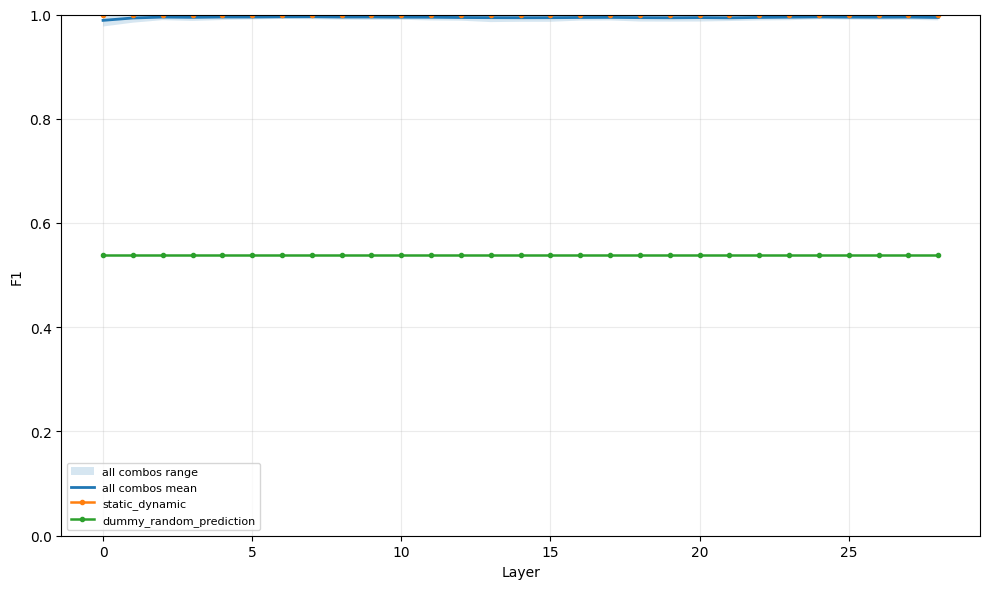

In [12]:
def plot_layerwise(results: pd.DataFrame, metric: str = 'f1') -> None:
    plt.figure(figsize=(10, 6))

    combo_results = results[results.experiment.str.startswith('language_bucket_combo_')]
    combo_by_layer = combo_results.groupby('layer')[metric]
    combo_layer_summary = combo_by_layer.agg(['mean', 'min', 'max']).reset_index()
    plt.fill_between(
        combo_layer_summary['layer'],
        combo_layer_summary['min'],
        combo_layer_summary['max'],
        alpha=0.18,
        label='all combos range',
    )
    plt.plot(
        combo_layer_summary['layer'],
        combo_layer_summary['mean'],
        linewidth=2,
        label='all combos mean',
    )

    for experiment in ['static_dynamic', 'dummy_random_prediction']:
        group = results[results.experiment == experiment].sort_values('layer')
        plt.plot(group['layer'], group[metric], marker='o', linewidth=1.8, markersize=3, label=experiment)

    plt.xlabel('Layer')
    plt.ylabel(metric.upper())
    plt.ylim(0.0, 1.0)
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'language_bucket_probe_plot.png', dpi=200)
    plt.show()


plot_layerwise(results)

In [13]:
# Distinct color palette for all PCA plots
LANG_COLORS = {
    'C':          '#1f77b4',  # steel blue
    'C#':         '#9467bd',  # purple
    'C++':        '#d62728',  # red
    'Java':       '#e6ab00',  # amber/gold
    'Javascript': '#2ca02c',  # forest green
    'PHP':        '#8c564b',  # brown
    'Python':     '#e377c2',  # pink/magenta
}


In [14]:
from sklearn.decomposition import PCA

PCA_LAYER = 4
PCA_ACTIVATION_DIR = CONTROL_DIR / 'activations/qwen25_coder_1p5b_last'
N_PCA_COMPONENTS = 20
FORCE_REEXTRACT_PCA = False


def extract_last_token_activations(force: bool = False) -> tuple[np.ndarray, list[dict]]:
    paths = {
        'features': PCA_ACTIVATION_DIR / 'features.npy',
        'labels':   PCA_ACTIVATION_DIR / 'labels.npy',
        'metadata': PCA_ACTIVATION_DIR / 'metadata.jsonl',
    }
    if not force and all(p.exists() for p in paths.values()):
        print(f'Using cached last-token activations in {PCA_ACTIVATION_DIR}')
        return np.load(paths['features'], mmap_mode='r'), read_jsonl(paths['metadata'])

    PCA_ACTIVATION_DIR.mkdir(parents=True, exist_ok=True)

    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    records = read_jsonl(DATA_DIR / 'static_dynamic.jsonl')
    grouped = group_records(records)
    device = pick_device()
    print(f'Extracting last-token activations on {device} ...')

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    dtype = torch.float16 if device.type in {'cuda', 'mps'} else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=dtype, trust_remote_code=True, low_cpu_mem_usage=True,
    )
    model.to(device).eval()

    all_features: List[np.ndarray] = []
    all_labels: List[int] = []
    all_metadata: List[dict] = []

    with torch.no_grad():
        for batch_start in range(0, len(grouped), 4):
            groups = grouped[batch_start : batch_start + 4]
            codes = [g[0]['code'] for g in groups]
            encoded = tokenizer(codes, return_tensors='pt', padding=True, truncation=True, max_length=512)
            attention_mask = encoded['attention_mask']
            encoded = {k: v.to(device) for k, v in encoded.items()}
            outputs = model(**encoded, output_hidden_states=True, use_cache=False)
            hidden_by_layer = torch.stack([s.detach().float().cpu() for s in outputs.hidden_states])

            for item_idx, group in enumerate(groups):
                item_mask = attention_mask[item_idx]
                layer_vecs = [
                    pool_layer(hidden_by_layer[li, item_idx], item_mask, 'last').numpy()
                    for li in range(hidden_by_layer.shape[0])
                ]
                program_features = np.stack(layer_vecs, axis=0)
                for record in group:
                    all_features.append(program_features)
                    all_labels.append(record['label'])
                    meta = dict(record)
                    meta['pooling'] = 'last'
                    all_metadata.append(meta)

            if batch_start and batch_start % 200 == 0:
                print(f'  {batch_start} / {len(grouped)} programs')

    features = np.stack(all_features, axis=0)
    np.save(paths['features'], features)
    np.save(paths['labels'], np.asarray(all_labels, dtype=np.int64))
    save_metadata(paths['metadata'], all_metadata)
    print(f'Saved last-token features {features.shape} to {PCA_ACTIVATION_DIR}')
    return features, all_metadata


def run_pca(features, metadata, layer, n_components=N_PCA_COMPONENTS):
    X = np.asarray(features[:, layer, :])
    pca = PCA(n_components=n_components, random_state=SEED)
    coords = pca.fit_transform(X)
    languages_arr = np.asarray([row['language'] for row in metadata])
    buckets_arr = np.asarray(
        ['static' if row['language'] in STATIC_LANGUAGES else 'dynamic' for row in metadata]
    )
    return coords, pca, languages_arr, buckets_arr


def plot_pca(coords, pca, languages_arr, buckets_arr, layer):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'PCA — Qwen2.5-Coder-1.5B last-token activations  (layer {layer})', fontsize=12)

    ax = axes[0]
    for lang in LANGUAGES:
        mask = languages_arr == lang
        ax.scatter(coords[mask, 0], coords[mask, 1], color=LANG_COLORS[lang],
                   label=lang, alpha=0.35, s=8, linewidths=0)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('By language')
    ax.legend(fontsize=7, markerscale=2.5)

    ax = axes[1]
    for bucket, color in [('static', '#2196F3'), ('dynamic', '#FF5722')]:
        mask = buckets_arr == bucket
        ax.scatter(coords[mask, 0], coords[mask, 1], color=color,
                   label=bucket, alpha=0.35, s=8, linewidths=0)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('By static / dynamic')
    ax.legend(fontsize=8, markerscale=2.5)

    ax = axes[2]
    evr = pca.explained_variance_ratio_
    cumvar = np.cumsum(evr)
    x = np.arange(1, len(evr) + 1)
    ax.bar(x, evr, alpha=0.7, label='per-component')
    ax.plot(x, cumvar, 'r-o', markersize=4, linewidth=1.5, label='cumulative')
    ax.set_xlabel('Principal Component'); ax.set_ylabel('Explained Variance Ratio')
    ax.set_title('Scree plot'); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'pca_layer{layer}.png', dpi=200)
    plt.show()
    print(f'PC1: {evr[0]:.1%}  PC2: {evr[1]:.1%}  top-5 cumulative: {np.cumsum(evr)[4]:.1%}')


Extracting last-token activations on cuda ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  200 / 19471 programs
  400 / 19471 programs
  600 / 19471 programs
  800 / 19471 programs
  1000 / 19471 programs
  1200 / 19471 programs
  1400 / 19471 programs
  1600 / 19471 programs
  1800 / 19471 programs
  2000 / 19471 programs
  2200 / 19471 programs
  2400 / 19471 programs
  2600 / 19471 programs
  2800 / 19471 programs
  3000 / 19471 programs
  3200 / 19471 programs
  3400 / 19471 programs
  3600 / 19471 programs
  3800 / 19471 programs
  4000 / 19471 programs
  4200 / 19471 programs
  4400 / 19471 programs
  4600 / 19471 programs
  4800 / 19471 programs
  5000 / 19471 programs
  5200 / 19471 programs
  5400 / 19471 programs
  5600 / 19471 programs
  5800 / 19471 programs
  6000 / 19471 programs
  6200 / 19471 programs
  6400 / 19471 programs
  6600 / 19471 programs
  6800 / 19471 programs
  7000 / 19471 programs
  7200 / 19471 programs
  7400 / 19471 programs
  7600 / 19471 programs
  7800 / 19471 programs
  8000 / 19471 programs
  8200 / 19471 programs
  8400 / 19471 progr

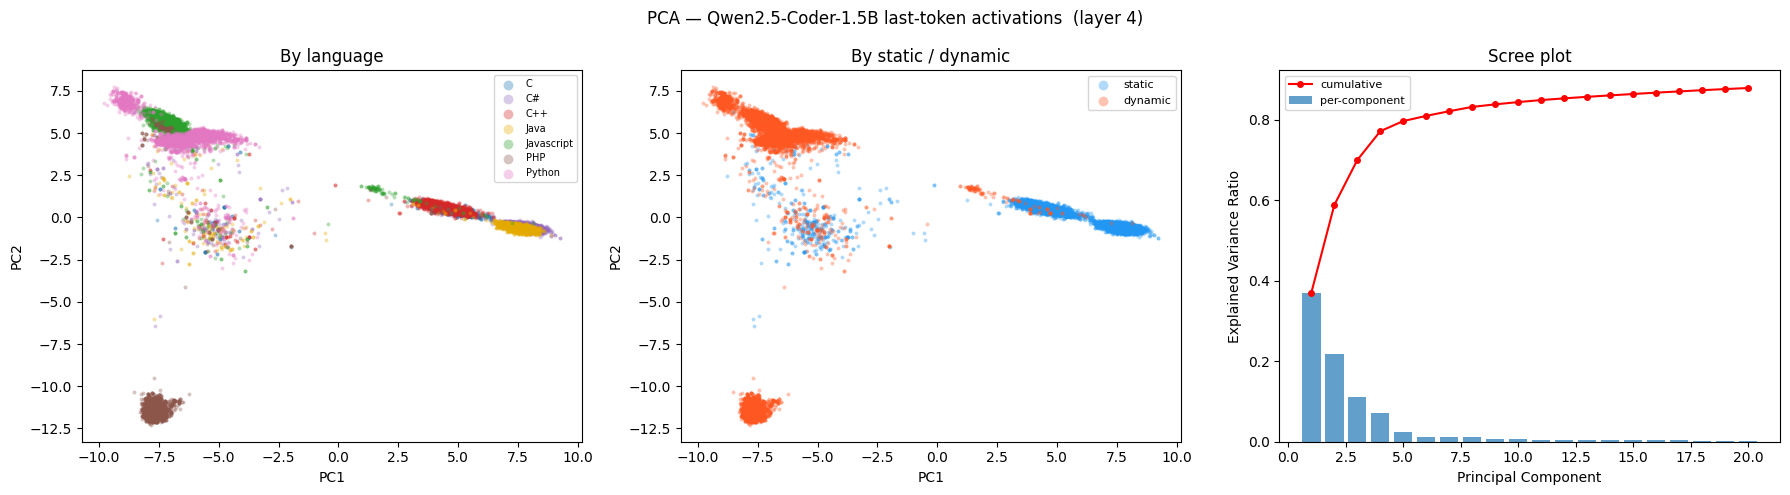

PC1: 37.0%  PC2: 21.8%  top-5 cumulative: 79.6%


In [15]:
pca_features, pca_metadata = extract_last_token_activations(force=FORCE_REEXTRACT_PCA)
coords, pca_model, languages_arr, buckets_arr = run_pca(pca_features, pca_metadata, layer=PCA_LAYER)
plot_pca(coords, pca_model, languages_arr, buckets_arr, layer=PCA_LAYER)

In [16]:
from scipy.stats import pointbiserialr

labels_arr = (buckets_arr == 'static').astype(int)
print('Point-biserial correlation of each PC with the static/dynamic label:')
for i in range(min(10, coords.shape[1])):
    r, p = pointbiserialr(labels_arr, coords[:, i])
    print(f'  PC{i+1:2d}: r = {r:+.3f}  p = {p:.2e}')

Point-biserial correlation of each PC with the static/dynamic label:
  PC 1: r = +0.941  p = 0.00e+00
  PC 2: r = -0.014  p = 5.34e-02
  PC 3: r = +0.026  p = 2.40e-04
  PC 4: r = +0.171  p = 9.31e-128
  PC 5: r = -0.141  p = 6.64e-87
  PC 6: r = -0.040  p = 3.31e-08
  PC 7: r = -0.002  p = 7.90e-01
  PC 8: r = -0.032  p = 7.29e-06
  PC 9: r = -0.021  p = 4.14e-03
  PC10: r = +0.004  p = 5.62e-01


Computing PCA for all layers...
Done.


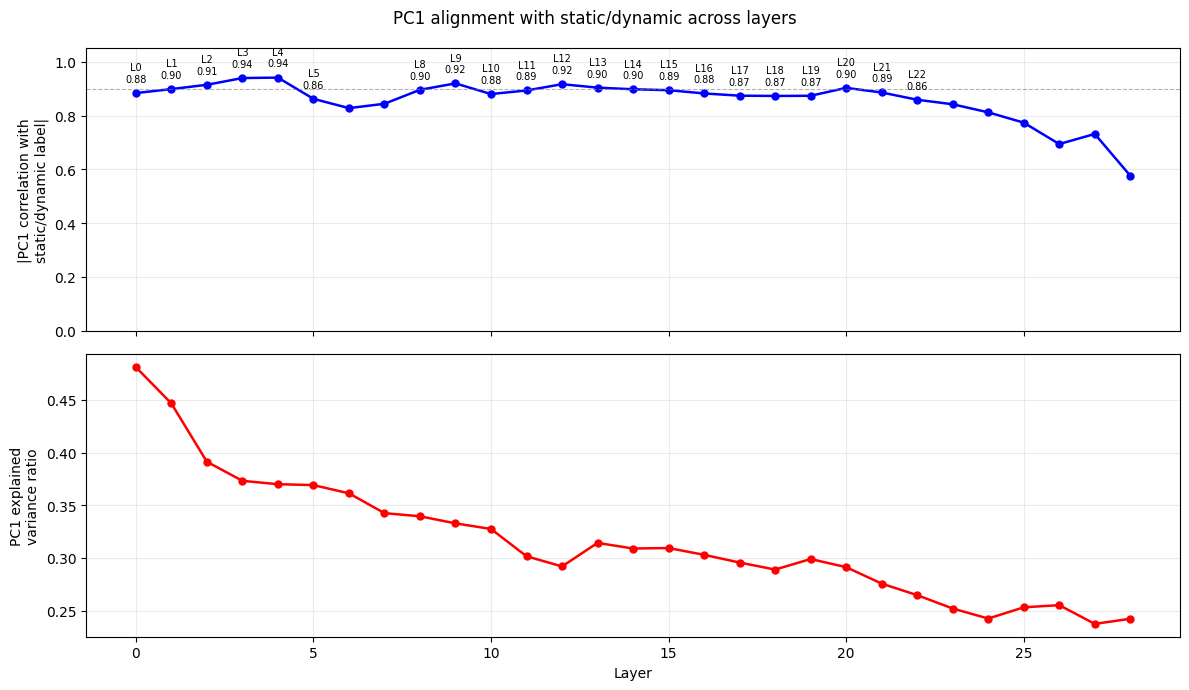

 layer         r    abs_r  evr_pc1
     0  0.883461 0.883461 0.481080
     1  0.898370 0.898370 0.446606
     2 -0.914279 0.914279 0.391240
     3 -0.939375 0.939375 0.373117
     4  0.941026 0.941026 0.369915
     5 -0.862136 0.862136 0.369048
     6 -0.827590 0.827590 0.361266
     7 -0.843702 0.843702 0.342445
     8  0.895673 0.895673 0.339452
     9 -0.919471 0.919471 0.332718
    10 -0.879951 0.879951 0.327421
    11 -0.893122 0.893122 0.301522
    12 -0.916510 0.916510 0.291851
    13  0.903709 0.903709 0.314201
    14  0.897667 0.897667 0.308859
    15  0.894254 0.894254 0.309320
    16  0.882167 0.882167 0.302876
    17 -0.873785 0.873785 0.295541
    18 -0.872816 0.872816 0.288884
    19 -0.873475 0.873475 0.298879
    20 -0.902821 0.902821 0.291157
    21 -0.885755 0.885755 0.275554
    22 -0.858713 0.858713 0.264587
    23 -0.841896 0.841896 0.251916
    24 -0.811933 0.811933 0.242361
    25 -0.773578 0.773578 0.253051
    26 -0.694001 0.694001 0.255076
    27 -0.731551 0.7

In [17]:
from sklearn.decomposition import PCA
from scipy.stats import pointbiserialr

_languages_arr = np.asarray([row['language'] for row in pca_metadata])
_buckets_arr   = np.asarray(['static' if row['language'] in STATIC_LANGUAGES else 'dynamic' for row in pca_metadata])
_labels_arr    = (_buckets_arr == 'static').astype(int)

print('Computing PCA for all layers...')
_layer_corrs = []
for _layer in range(pca_features.shape[1]):
    _X = np.asarray(pca_features[:, _layer, :])
    _pca = PCA(n_components=2, random_state=SEED)
    _c   = _pca.fit_transform(_X)
    _r, _ = pointbiserialr(_labels_arr, _c[:, 0])
    _layer_corrs.append({'layer': _layer, 'r': _r, 'abs_r': abs(_r), 'evr_pc1': _pca.explained_variance_ratio_[0]})
print('Done.')

_corr_df = pd.DataFrame(_layer_corrs)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('PC1 alignment with static/dynamic across layers', fontsize=12)

ax = axes[0]
ax.plot(_corr_df['layer'], _corr_df['abs_r'], 'b-o', markersize=5, linewidth=1.8)
ax.set_ylabel('|PC1 correlation with\nstatic/dynamic label|')
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(True, alpha=0.25)
for _, row in _corr_df.iterrows():
    if row['abs_r'] > 0.85:
        ax.annotate(f"L{int(row['layer'])}\n{row['abs_r']:.2f}",
                    (row['layer'], row['abs_r']),
                    textcoords='offset points', xytext=(0, 8), fontsize=7, ha='center')

ax = axes[1]
ax.plot(_corr_df['layer'], _corr_df['evr_pc1'], 'r-o', markersize=5, linewidth=1.8)
ax.set_xlabel('Layer')
ax.set_ylabel('PC1 explained\nvariance ratio')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pca_pc1_correlation_by_layer.png', dpi=200)
plt.show()
print(_corr_df[['layer', 'r', 'abs_r', 'evr_pc1']].to_string(index=False))


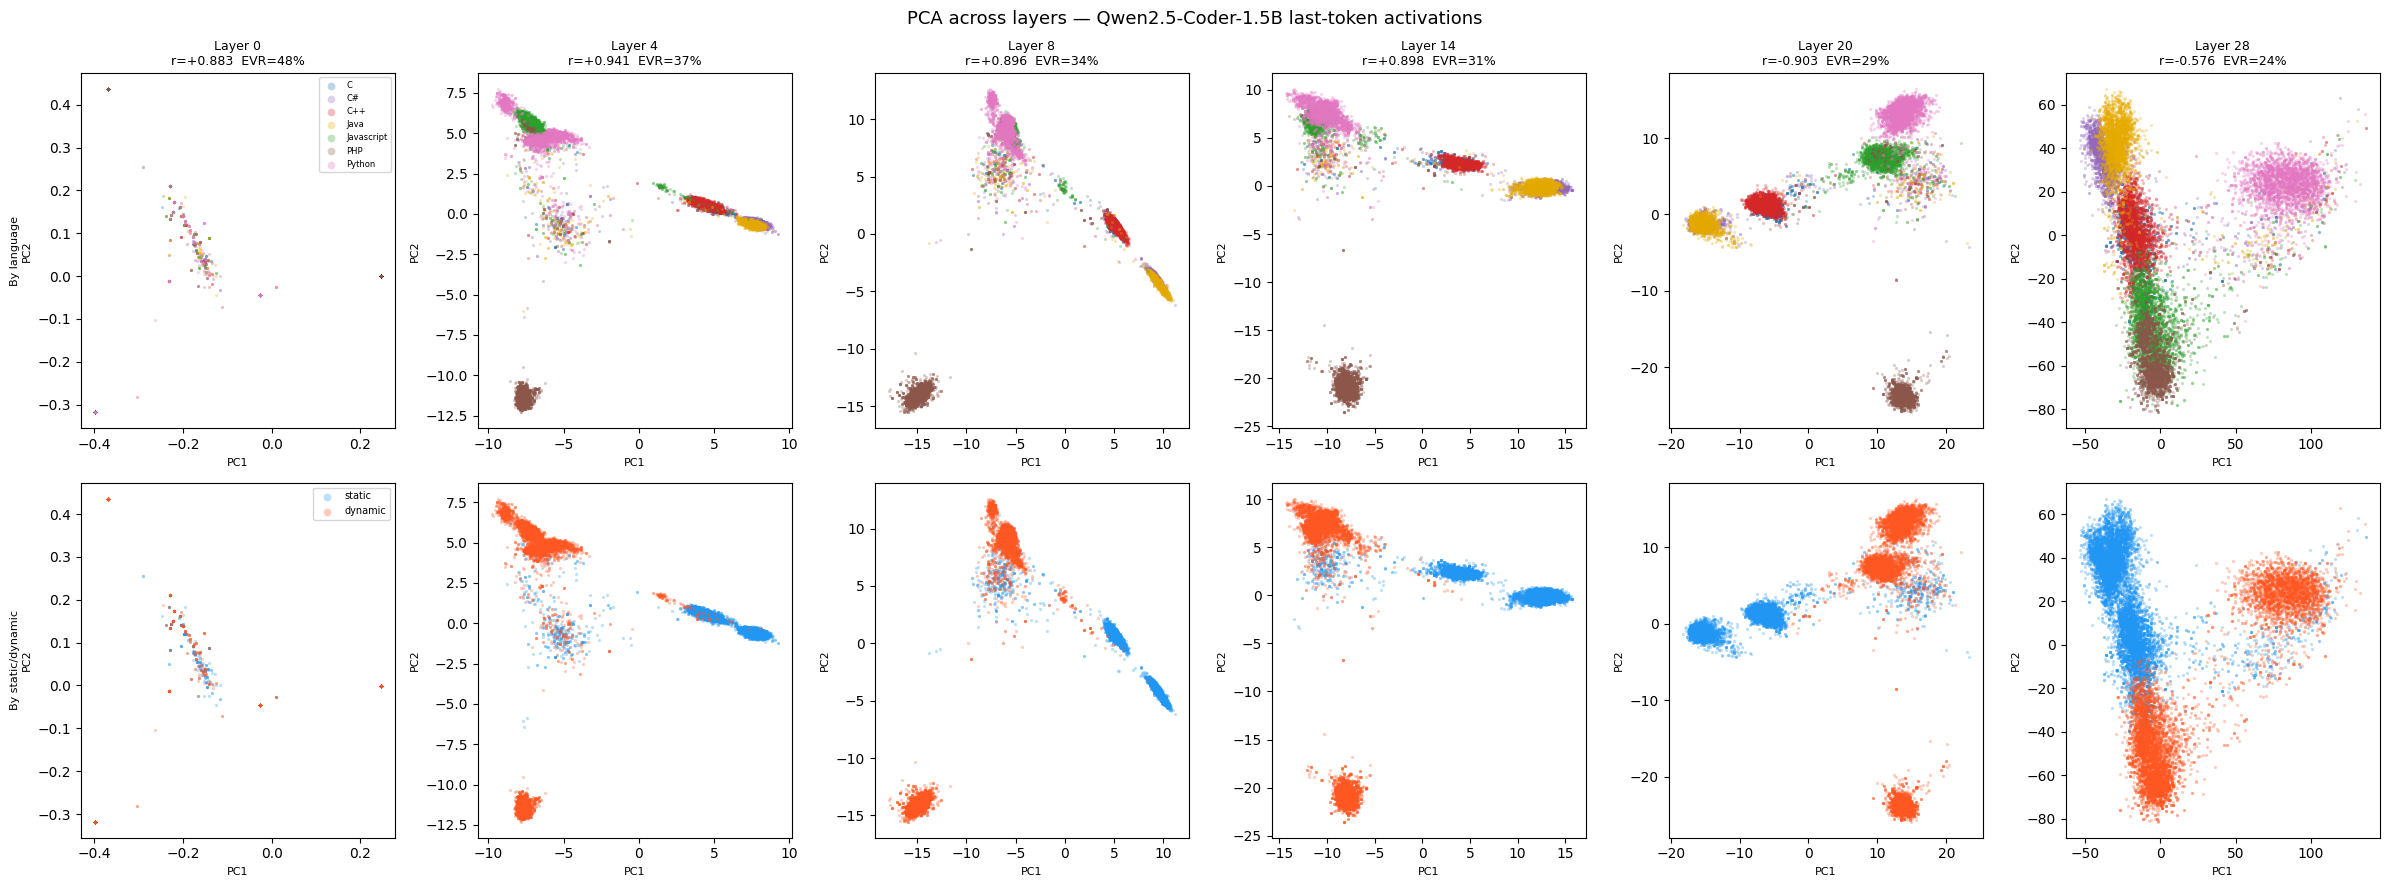

In [18]:
SELECTED_LAYERS = [0, 4, 8, 14, 20, 28]

fig, axes = plt.subplots(2, len(SELECTED_LAYERS), figsize=(4 * len(SELECTED_LAYERS), 9))
fig.suptitle('PCA across layers — Qwen2.5-Coder-1.5B last-token activations', fontsize=13)

for col, layer in enumerate(SELECTED_LAYERS):
    _X  = np.asarray(pca_features[:, layer, :])
    _pl = PCA(n_components=2, random_state=SEED)
    _c  = _pl.fit_transform(_X)
    _r, _ = pointbiserialr(_labels_arr, _c[:, 0])
    _evr  = _pl.explained_variance_ratio_

    ax = axes[0, col]
    for lang in LANGUAGES:
        mask = _languages_arr == lang
        ax.scatter(_c[mask, 0], _c[mask, 1], color=LANG_COLORS[lang],
                   label=lang, alpha=0.3, s=5, linewidths=0)
    ax.set_title(f'Layer {layer}\nr={_r:+.3f}  EVR={_evr[0]:.0%}', fontsize=9)
    ax.set_xlabel('PC1', fontsize=8); ax.set_ylabel('PC2', fontsize=8)
    if col == 0:
        ax.legend(fontsize=6, markerscale=2.5)

    ax = axes[1, col]
    for bucket, color in [('static', '#2196F3'), ('dynamic', '#FF5722')]:
        mask = _buckets_arr == bucket
        ax.scatter(_c[mask, 0], _c[mask, 1], color=color,
                   label=bucket, alpha=0.3, s=5, linewidths=0)
    ax.set_xlabel('PC1', fontsize=8); ax.set_ylabel('PC2', fontsize=8)
    if col == 0:
        ax.legend(fontsize=7, markerscale=2.5)

axes[0, 0].set_ylabel('By language\nPC2', fontsize=8)
axes[1, 0].set_ylabel('By static/dynamic\nPC2', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pca_multi_layer.png', dpi=150)
plt.show()


Pre-computing PCA for animation...
Done.
GIF saved → /content/language_bucket_control/results/pca_layerwise_animation.gif


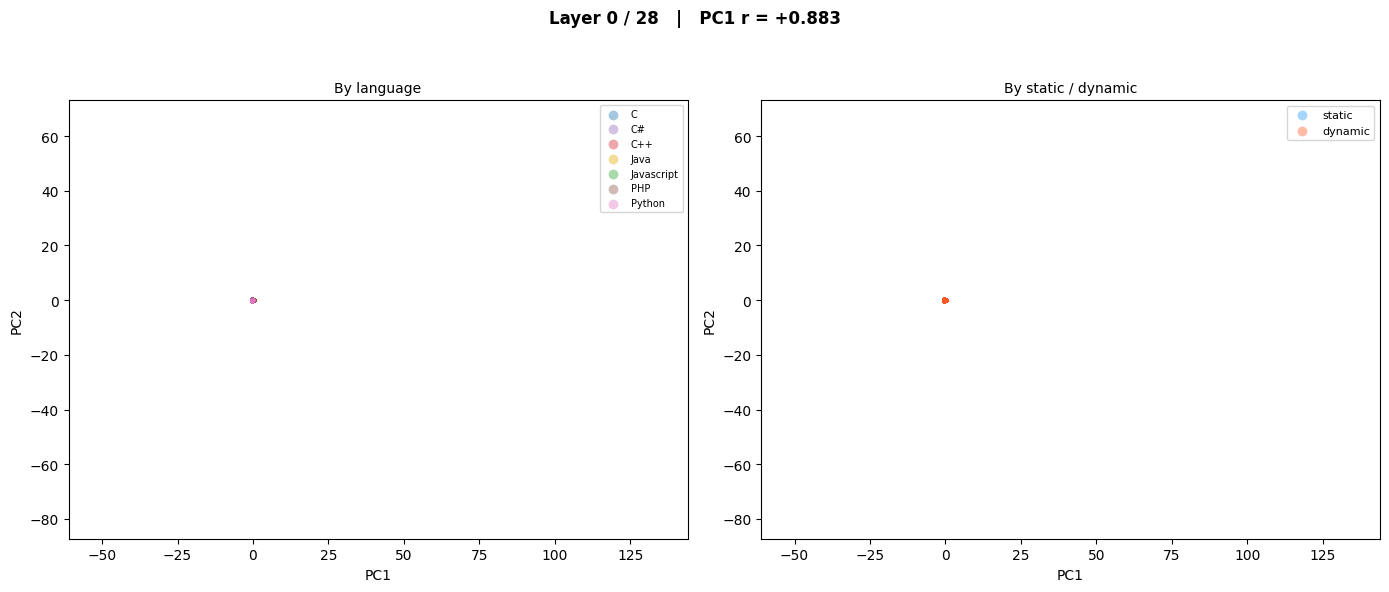

In [19]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

print('Pre-computing PCA for animation...')
_all_coords, _all_rs = [], []
for _layer in range(pca_features.shape[1]):
    _X = np.asarray(pca_features[:, _layer, :])
    _pca_l = PCA(n_components=2, random_state=SEED)
    _c = _pca_l.fit_transform(_X)
    _r, _ = pointbiserialr(_labels_arr, _c[:, 0])
    _all_coords.append(_c)
    _all_rs.append(_r)
print('Done.')

_all_stacked = np.concatenate(_all_coords, axis=0)
_xpad = (_all_stacked[:, 0].max() - _all_stacked[:, 0].min()) * 0.04
_ypad = (_all_stacked[:, 1].max() - _all_stacked[:, 1].min()) * 0.04
_xlim = (_all_stacked[:, 0].min() - _xpad, _all_stacked[:, 0].max() + _xpad)
_ylim = (_all_stacked[:, 1].min() - _ypad, _all_stacked[:, 1].max() + _ypad)

_cmap2        = plt.colormaps['tab10'].resampled(len(LANGUAGES))
_static_mask  = _buckets_arr == 'static'
_dynamic_mask = ~_static_mask
_n_layers     = pca_features.shape[1]

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

def _draw(layer):
    for ax in axes2: ax.cla()
    _c = _all_coords[layer]
    _r = _all_rs[layer]
    ax0, ax1 = axes2

    for lang in LANGUAGES:
        mask = _languages_arr == lang
        ax0.scatter(_c[mask, 0], _c[mask, 1], color=LANG_COLORS[lang],
                    label=lang, alpha=0.4, s=8, linewidths=0)
    ax0.set_title('By language', fontsize=10)
    ax0.set_xlabel('PC1'); ax0.set_ylabel('PC2')
    ax0.set_xlim(*_xlim); ax0.set_ylim(*_ylim)
    ax0.legend(fontsize=7, markerscale=2.5, loc='upper right')

    ax1.scatter(_c[_static_mask,  0], _c[_static_mask,  1], color='#2196F3',
                label='static',  alpha=0.4, s=8, linewidths=0)
    ax1.scatter(_c[_dynamic_mask, 0], _c[_dynamic_mask, 1], color='#FF5722',
                label='dynamic', alpha=0.4, s=8, linewidths=0)
    ax1.set_title('By static / dynamic', fontsize=10)
    ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
    ax1.set_xlim(*_xlim); ax1.set_ylim(*_ylim)
    ax1.legend(fontsize=8, markerscale=2.5, loc='upper right')

    fig2.suptitle(f'Layer {layer} / {_n_layers - 1}   |   PC1 r = {_r:+.3f}',
                  fontsize=12, fontweight='bold')
    fig2.tight_layout(rect=[0, 0, 1, 0.94])

_anim = FuncAnimation(fig2, _draw, frames=_n_layers, interval=700)
_anim.save(RESULTS_DIR / 'pca_layerwise_animation.gif', writer='pillow', fps=2, dpi=100)
print(f'GIF saved → {RESULTS_DIR}/pca_layerwise_animation.gif')
HTML(_anim.to_jshtml())


In [20]:
# Count snippets per language first
from collections import Counter
lang_counts = Counter(row['language'] for row in pca_metadata)
print("Snippet counts per language:")
for lang in LANGUAGES:
    print(f"  {lang:12s}: {lang_counts[lang]}")

print(f"\nMin count (C): {lang_counts['C']}")


Snippet counts per language:
  C           : 1633
  C#          : 3000
  C++         : 3000
  Java        : 3000
  Javascript  : 3000
  PHP         : 2838
  Python      : 3000

Min count (C): 1633


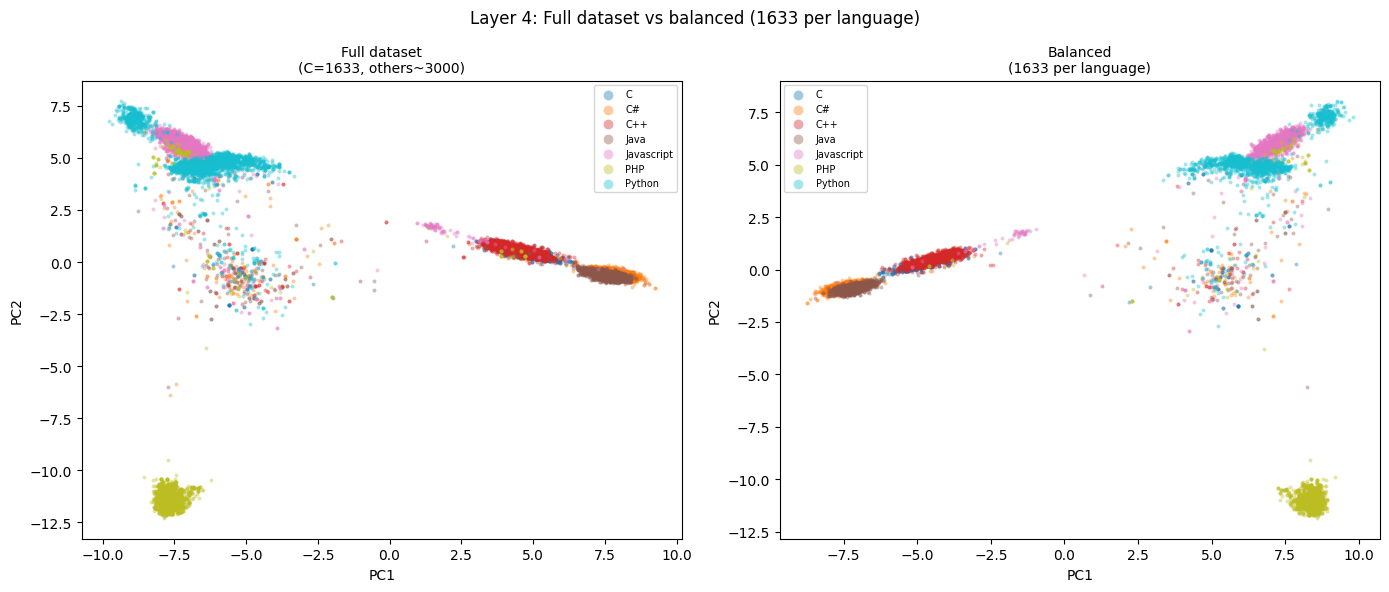

In [21]:
# Subsample all languages to C's count, re-run PCA, compare
from sklearn.decomposition import PCA
from scipy.stats import pointbiserialr

MIN_COUNT = lang_counts['C']
BALANCED_LAYER = 4  # use layer 4 where structure was clearest

# Build balanced index
np.random.seed(SEED)
balanced_idx = []
for lang in LANGUAGES:
    lang_idx = [i for i, row in enumerate(pca_metadata) if row['language'] == lang]
    sampled = np.random.choice(lang_idx, size=MIN_COUNT, replace=False)
    balanced_idx.extend(sampled)
balanced_idx = np.array(balanced_idx)

_languages_balanced = np.asarray([pca_metadata[i]['language'] for i in balanced_idx])
_buckets_balanced   = np.asarray(['static' if pca_metadata[i]['language'] in STATIC_LANGUAGES else 'dynamic' for i in balanced_idx])

X_full     = np.asarray(pca_features[:, BALANCED_LAYER, :])
X_balanced = X_full[balanced_idx]

pca_full = PCA(n_components=2, random_state=SEED)
pca_bal  = PCA(n_components=2, random_state=SEED)
c_full = pca_full.fit_transform(X_full)
c_bal  = pca_bal.fit_transform(X_balanced)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Layer {BALANCED_LAYER}: Full dataset vs balanced ({MIN_COUNT} per language)', fontsize=12)

cmap = plt.colormaps['tab10'].resampled(len(LANGUAGES))

for col, (coords, langs, title) in enumerate([
    (c_full, np.asarray([row['language'] for row in pca_metadata]), f'Full dataset\n(C={lang_counts["C"]}, others~3000)'),
    (c_bal,  _languages_balanced, f'Balanced\n({MIN_COUNT} per language)'),
]):
    ax = axes[col]
    for i, lang in enumerate(LANGUAGES):
        mask = langs == lang
        ax.scatter(coords[mask, 0], coords[mask, 1], color=cmap(i),
                   label=lang, alpha=0.4, s=8, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=2.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pca_balanced_vs_full.png', dpi=150)
plt.show()


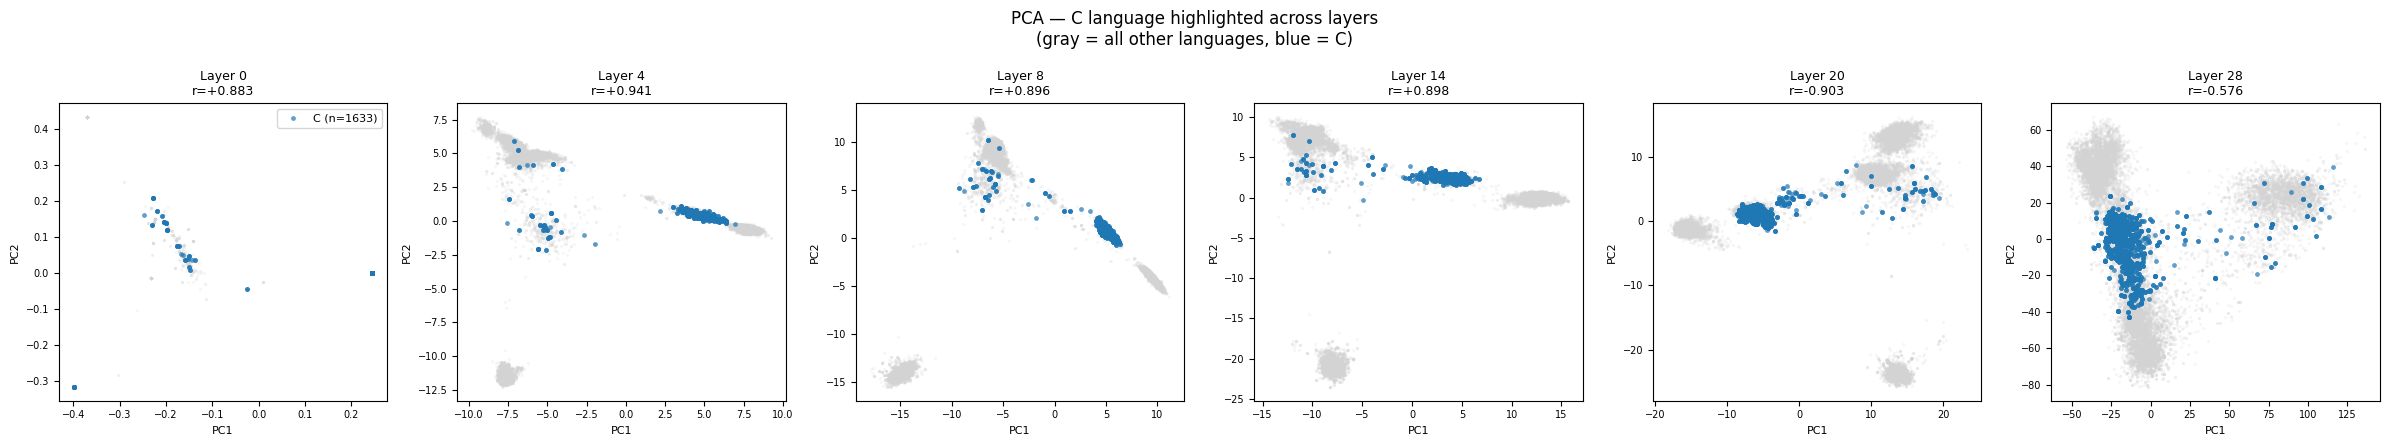

In [22]:
# Layer-by-layer PCA — C highlighted, all others grayed out
from sklearn.decomposition import PCA
from scipy.stats import pointbiserialr

SELECTED_LAYERS = [0, 4, 8, 14, 20, 28]
c_mask = _languages_arr == 'C'

fig, axes = plt.subplots(1, len(SELECTED_LAYERS), figsize=(4 * len(SELECTED_LAYERS), 4.5))
fig.suptitle('PCA — C language highlighted across layers\n(gray = all other languages, blue = C)', fontsize=12)

for col, layer in enumerate(SELECTED_LAYERS):
    X   = np.asarray(pca_features[:, layer, :])
    pca_l = PCA(n_components=2, random_state=SEED)
    coords = pca_l.fit_transform(X)
    r_val, _ = pointbiserialr(_labels_arr, coords[:, 0])

    ax = axes[col]
    # All other languages as faded gray background
    ax.scatter(coords[~c_mask, 0], coords[~c_mask, 1],
               color='lightgray', alpha=0.2, s=5, linewidths=0)
    # C points in blue, prominent
    ax.scatter(coords[c_mask, 0], coords[c_mask, 1],
               color=LANG_COLORS['C'], alpha=0.7, s=12, linewidths=0, label=f'C (n={c_mask.sum()})')

    ax.set_title(f'Layer {layer}\nr={r_val:+.3f}', fontsize=9)
    ax.set_xlabel('PC1', fontsize=8)
    ax.set_ylabel('PC2', fontsize=8)
    ax.tick_params(labelsize=7)
    if col == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pca_c_highlighted.png', dpi=150)
plt.show()


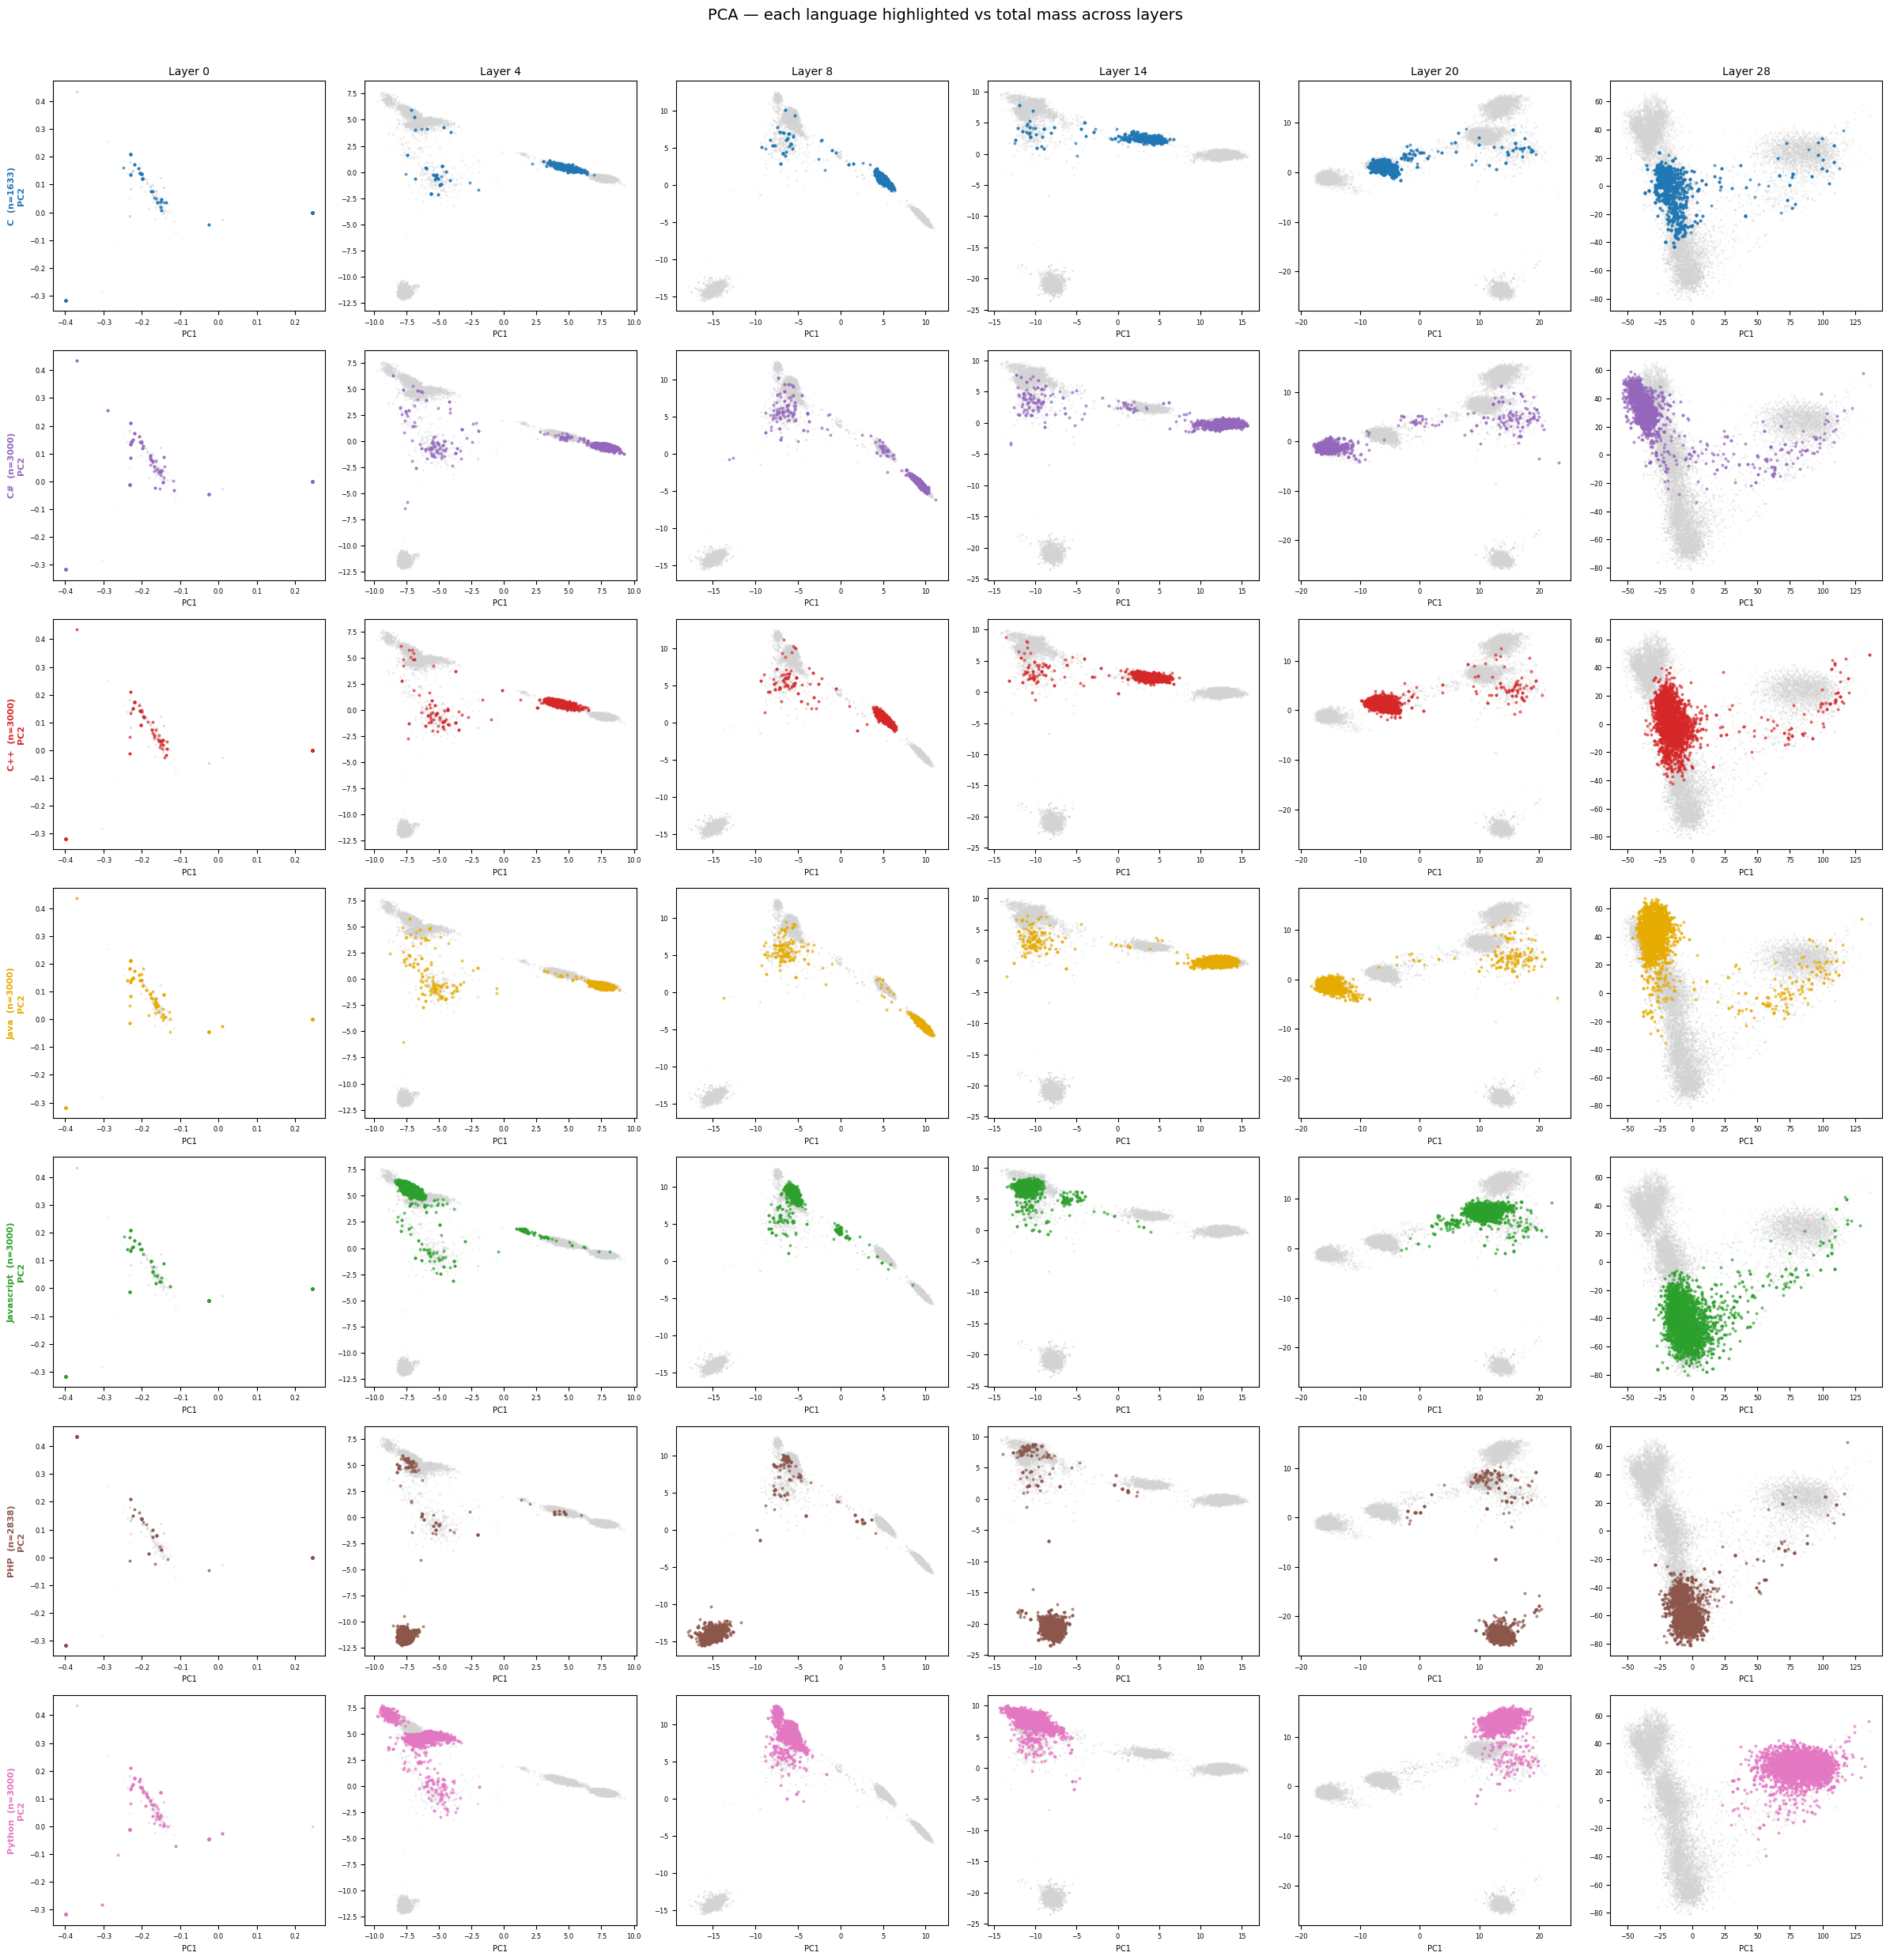

In [23]:
from sklearn.decomposition import PCA
from scipy.stats import pointbiserialr

SELECTED_LAYERS = [0, 4, 8, 14, 20, 28]

# Compute PCA once per layer (reuse across all language rows)
layer_coords = {}
for layer in SELECTED_LAYERS:
    X = np.asarray(pca_features[:, layer, :])
    pca_l = PCA(n_components=2, random_state=SEED)
    layer_coords[layer] = pca_l.fit_transform(X)

fig, axes = plt.subplots(
    len(LANGUAGES), len(SELECTED_LAYERS),
    figsize=(4 * len(SELECTED_LAYERS), 3.5 * len(LANGUAGES))
)
fig.suptitle('PCA — each language highlighted vs total mass across layers', fontsize=14, y=1.01)

for row, lang in enumerate(LANGUAGES):
    lang_mask = _languages_arr == lang
    n = lang_mask.sum()

    for col, layer in enumerate(SELECTED_LAYERS):
        coords = layer_coords[layer]
        ax = axes[row, col]

        # Total mass in gray
        ax.scatter(coords[~lang_mask, 0], coords[~lang_mask, 1],
                   color='lightgray', alpha=0.2, s=4, linewidths=0)
        # This language highlighted
        ax.scatter(coords[lang_mask, 0], coords[lang_mask, 1],
                   color=LANG_COLORS[lang], alpha=0.7, s=8, linewidths=0)

        ax.tick_params(labelsize=6)

        if col == 0:
            ax.set_ylabel(f'{lang}  (n={n})\nPC2', fontsize=8, color=LANG_COLORS[lang], fontweight='bold')
        if row == 0:
            ax.set_title(f'Layer {layer}', fontsize=10)

        ax.set_xlabel('PC1', fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pca_each_language_vs_mass.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. 3D PCA — PC1, PC2, PC3

Adding a third principal component often reveals structure not visible in the 2D projection.
The cells below plot activations in 3D space, colored by language and by static/dynamic bucket.


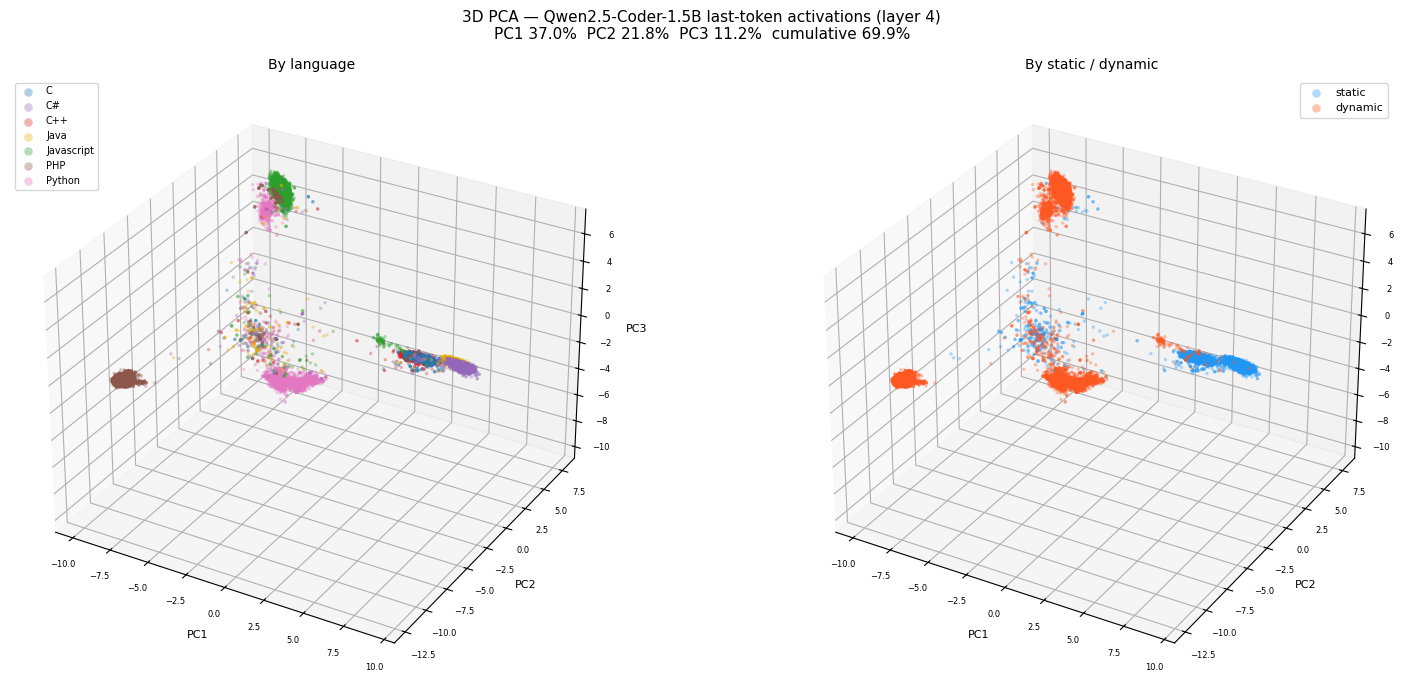

PC1: 37.0%  PC2: 21.8%  PC3: 11.2%  top-3 cumulative: 69.9%


In [24]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

PCA_3D_LAYER = 4

X = np.asarray(pca_features[:, PCA_3D_LAYER, :])
pca3 = PCA(n_components=3, random_state=SEED)
c3 = pca3.fit_transform(X)
evr3 = pca3.explained_variance_ratio_

fig = plt.figure(figsize=(16, 7))
fig.suptitle(
    f'3D PCA — Qwen2.5-Coder-1.5B last-token activations (layer {PCA_3D_LAYER})\n'
    f'PC1 {evr3[0]:.1%}  PC2 {evr3[1]:.1%}  PC3 {evr3[2]:.1%}  '
    f'cumulative {evr3[:3].sum():.1%}',
    fontsize=11,
)

# Left: by language
ax1 = fig.add_subplot(121, projection='3d')
for lang in LANGUAGES:
    mask = _languages_arr == lang
    ax1.scatter(c3[mask, 0], c3[mask, 1], c3[mask, 2],
                color=LANG_COLORS[lang], label=lang, alpha=0.35, s=6, linewidths=0)
ax1.set_xlabel('PC1', fontsize=8); ax1.set_ylabel('PC2', fontsize=8); ax1.set_zlabel('PC3', fontsize=8)
ax1.set_title('By language', fontsize=10)
ax1.legend(fontsize=7, markerscale=2.5, loc='upper left')
ax1.tick_params(labelsize=6)

# Right: by static / dynamic
ax2 = fig.add_subplot(122, projection='3d')
for bucket, color in [('static', '#2196F3'), ('dynamic', '#FF5722')]:
    mask = _buckets_arr == bucket
    ax2.scatter(c3[mask, 0], c3[mask, 1], c3[mask, 2],
                color=color, label=bucket, alpha=0.35, s=6, linewidths=0)
ax2.set_xlabel('PC1', fontsize=8); ax2.set_ylabel('PC2', fontsize=8); ax2.set_zlabel('PC3', fontsize=8)
ax2.set_title('By static / dynamic', fontsize=10)
ax2.legend(fontsize=8, markerscale=2.5)
ax2.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'pca3d_layer{PCA_3D_LAYER}.png', dpi=200)
plt.show()

print(f'PC1: {evr3[0]:.1%}  PC2: {evr3[1]:.1%}  PC3: {evr3[2]:.1%}  '
      f'top-3 cumulative: {evr3[:3].sum():.1%}')


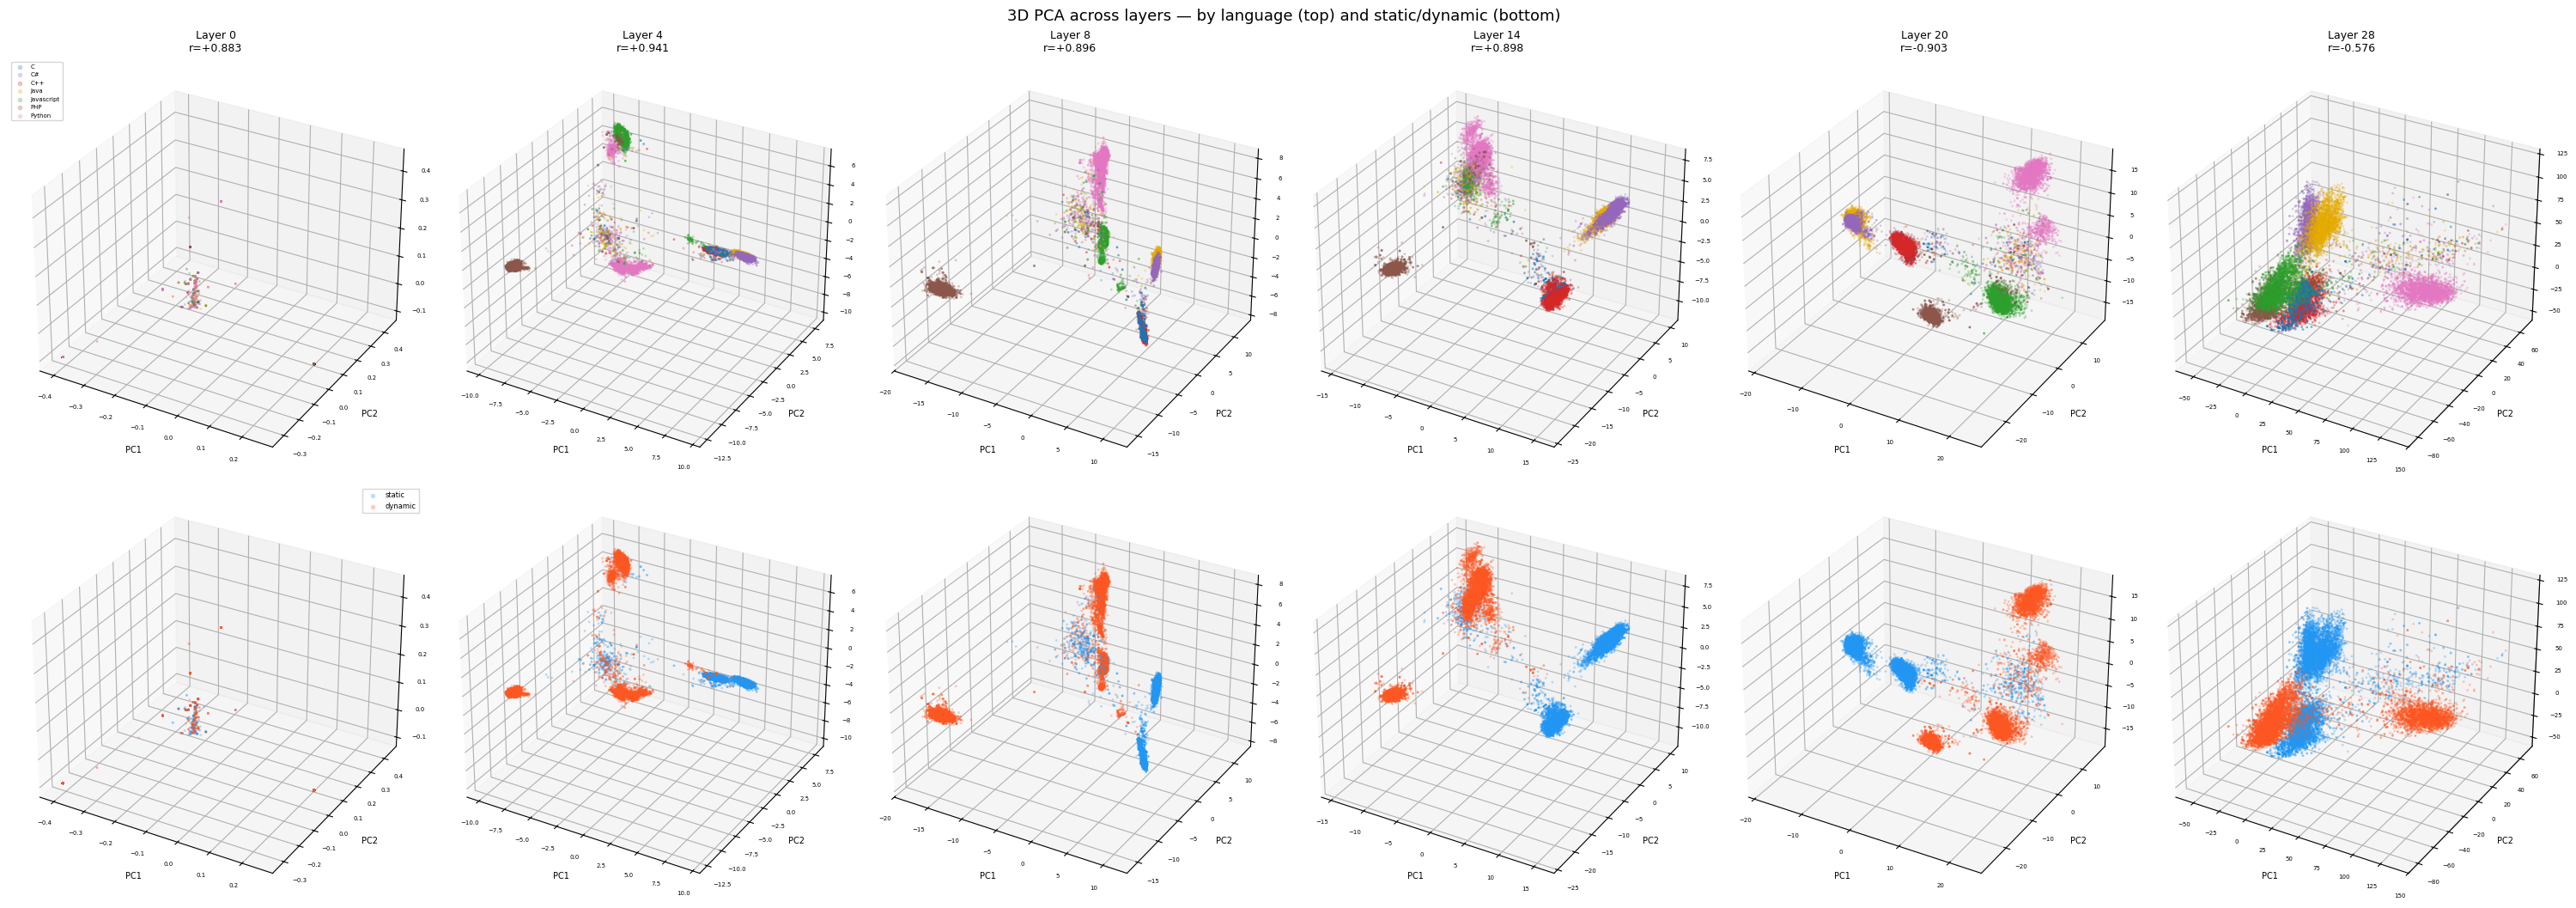

In [25]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

SELECTED_LAYERS_3D = [0, 4, 8, 14, 20, 28]

fig = plt.figure(figsize=(5 * len(SELECTED_LAYERS_3D), 11))
fig.suptitle('3D PCA across layers — by language (top) and static/dynamic (bottom)', fontsize=13)

for col, layer in enumerate(SELECTED_LAYERS_3D):
    X = np.asarray(pca_features[:, layer, :])
    pca_l = PCA(n_components=3, random_state=SEED)
    c = pca_l.fit_transform(X)
    evr = pca_l.explained_variance_ratio_
    r_val, _ = pointbiserialr(_labels_arr, c[:, 0])

    # Top row: by language
    ax = fig.add_subplot(2, len(SELECTED_LAYERS_3D), col + 1, projection='3d')
    for lang in LANGUAGES:
        mask = _languages_arr == lang
        ax.scatter(c[mask, 0], c[mask, 1], c[mask, 2],
                   color=LANG_COLORS[lang], label=lang, alpha=0.3, s=4, linewidths=0)
    ax.set_title(f'Layer {layer}\nr={r_val:+.3f}', fontsize=9)
    ax.set_xlabel('PC1', fontsize=7); ax.set_ylabel('PC2', fontsize=7); ax.set_zlabel('PC3', fontsize=7)
    ax.tick_params(labelsize=5)
    if col == 0:
        ax.legend(fontsize=5, markerscale=2, loc='upper left')

    # Bottom row: by static/dynamic
    ax2 = fig.add_subplot(2, len(SELECTED_LAYERS_3D), len(SELECTED_LAYERS_3D) + col + 1, projection='3d')
    for bucket, color in [('static', '#2196F3'), ('dynamic', '#FF5722')]:
        mask = _buckets_arr == bucket
        ax2.scatter(c[mask, 0], c[mask, 1], c[mask, 2],
                    color=color, label=bucket, alpha=0.3, s=4, linewidths=0)
    ax2.set_xlabel('PC1', fontsize=7); ax2.set_ylabel('PC2', fontsize=7); ax2.set_zlabel('PC3', fontsize=7)
    ax2.tick_params(labelsize=5)
    if col == 0:
        ax2.legend(fontsize=6, markerscale=2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pca3d_multi_layer.png', dpi=120, bbox_inches='tight')
plt.show()
